# A/B Test Analysis

## Analysis objectives
The objective of this analysis is to understand which version of the test A/B are the most valueable for the company.

For this, we will use the **orders_us.csv** and **visits_us.csv** which contains the results of the test, with the following columns/data:

**orders_us.csv**
- **transactionId** — order identifier
- **visitorId** — identifier of the user who placed the order
- **date** — order date
- **revenue** — order revenue
- **group** — A/B test group the user belongs to

**visits_us.csv**
- **date** — date
- **group** — A/B test group
- **visits** — number of visits on the specified date for the specified A/B test group


In [28]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
# Loading the orders and visits data from a CSV file
df_orders = pd.read_csv("../data/orders_us.csv", parse_dates=["date"])
df_visits = pd.read_csv("../data/visits_us.csv", parse_dates=["date"])

In [30]:
# Displaying dataframe orders information
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[us]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 46.9 KB


In [31]:
# Displaying the first few rows of the orders DataFrame
df_orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [32]:
# Displaying the total number of unique orders (transactions)
df_orders['transactionId'].nunique()

1197

In [33]:
# Checking for duplcated rows in the orders DataFrame
df_orders[df_orders.duplicated()].shape[0]

0

In [34]:
# Identifying visitors that belong to more than one group (A/B test groups)
unusefull_data = df_orders.groupby(
    'visitorId')['group'].nunique().loc[lambda x: x > 1].reset_index()

In [35]:
# Count of visitors that belong to more than one group
print(unusefull_data['visitorId'].count())

58


In [36]:
# Filtering out visitors that belong to more than one group from the orders DataFrame
df_orders_filtered = df_orders[df_orders['visitorId'].isin(
    unusefull_data['visitorId']) == False]

In [37]:
# Displaying the number of rows in the filtered orders DataFrame
print(df_orders.shape[0] - df_orders_filtered.shape[0])

181


In [38]:
# Displaying the group distribution per test
df_orders_filtered['group'].value_counts()

group
B    548
A    468
Name: count, dtype: int64

In [39]:
# Displaying the statistical summary of the 'revenue' column in the filtered orders DataFrame
df_orders_filtered['revenue'].describe()

count     1016.000000
mean       130.770866
std        648.079810
min          5.000000
25%         20.775000
50%         50.100000
75%        126.950000
max      19920.400000
Name: revenue, dtype: float64

In [40]:
# Displaying dataframe visits information
df_visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[us]
 1   group   62 non-null     str           
 2   visits  62 non-null     int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.6 KB


In [41]:
# Displaying first few rows of the visits DataFrame
df_visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [42]:
# Verifying dates range in both DataFrames
print(
    f"Orders date range: \"{df_orders_filtered['date'].min()}\" to \"{df_orders_filtered['date'].max()}\"")
print(
    f"Visits date range: \"{df_visits['date'].min()}\" to \"{df_visits['date'].max()}\"")

Orders date range: "2019-08-01 00:00:00" to "2019-08-31 00:00:00"
Visits date range: "2019-08-01 00:00:00" to "2019-08-31 00:00:00"


### EDA comments
- df_orders have no missing values or duplicated rows
- 'transctionId' uniqueness was verified
- 58 'visitorId' had acess to both tests A and B, 181 rows were removed from dataframe
- test 'A' had 468 orders and 'B' 548
- 'revenue' min and max values are in positive range; distribution seems to have a right-skewed distribution as 75% of data is bellow 126.95 (will be showed later in analysis)
- both dataframes are in the same dates range, from 01-aug-2019 to 31-aug-2019 (1 month)

## 1.Cumulative revenue per group

In [43]:
# Extracting unique date and group combinations
datesGroups = df_orders_filtered[['date', 'group']].drop_duplicates()

In [44]:
# Creating the dataframe with aggregated orders data by date and group
ordersAggregated = datesGroups.apply(
    # For each date and group combination, we filter the orders DataFrame
    lambda x: df_orders_filtered[
        # Include only rows where the date is less than or equal to the current date and the group matches the current group
        np.logical_and(
            df_orders_filtered['date'] <= x['date'], df_orders_filtered['group'] == x['group'])].agg(
        {
            # Get the max date (which is the same as the current date)
            'date': 'max',
            # Get the max group (which is the same as the current group)
            'group': 'max',
            # Count the number of unique orders (transactions)
            'transactionId': pd.Series.nunique,
            # Count the number of unique users (visitors)
            'visitorId': pd.Series.nunique,
            'revenue': 'sum',  # Sum the revenue for the current date and group
        }
    ), axis=1  # Apply the aggregation function along the rows
    # Sort the resulting DataFrame by date and group
).sort_values(by=['date', 'group'])

In [45]:
print(ordersAggregated.head())

          date group  transactionId  visitorId  revenue
55  2019-08-01     A             23         19   2266.6
66  2019-08-01     B             17         17    967.2
175 2019-08-02     A             42         36   3734.9
173 2019-08-02     B             40         39   3535.3
291 2019-08-03     A             66         60   5550.1


In [46]:
# Creating a DataFrame for cumulative revenue of group A
cumulativeRevenueA = ordersAggregated[ordersAggregated['group'] == 'A'][[
    'date', 'revenue']].reset_index(drop=True)

In [47]:
# Creating a DataFrame for cumulative revenue of group B
cumulativeRevenueB = ordersAggregated[ordersAggregated['group'] == 'B'][[
    'date', 'revenue']].reset_index(drop=True)

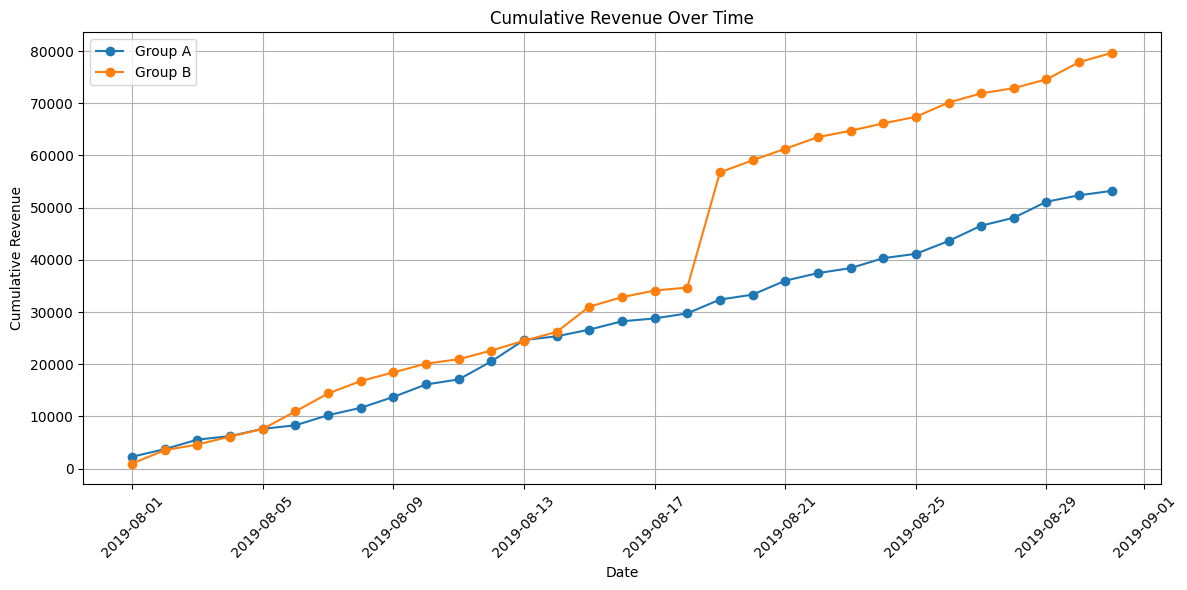

In [48]:
# Plotting cumulative revenue for both groups
plt.figure(figsize=(12, 6))
plt.plot(cumulativeRevenueA['date'],
         cumulativeRevenueA['revenue'], label='Group A', marker='o')
plt.plot(cumulativeRevenueB['date'],
         cumulativeRevenueB['revenue'], label='Group B', marker='o')
plt.title('Cumulative Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Cumulative revenue per group - observations
- Both groups show a steady, roughly linear increase in cumulative revenue over the month, which is expected for a cumulative metric.
- Group B has a higher cumulative revenue than group A from around day 5 onwards, but the gap stays small and fairly constant until day 19.
- On day 19, group B's cumulative revenue jumps sharply. This is likely caused by one or a few very large orders (outliers), rather than a real change in user behavior.
- Because of this spike, group B ends the month clearly ahead of group A, but this lead may be driven mostly by that single anomaly.
- This needs to be checked further: in the next steps we will look at order prices and percentiles and compare the results with and without outliers to see if group B is really performing better.

## 2.Cumulative average ticket per group

In [ ]:
# Adding cumulative orders count column to the cumulativeRevenueA DataFrame
cumulativeRevenueA['orders'] = ordersAggregated[ordersAggregated['group']
                                                == 'A']['transactionId'].reset_index(drop=True)

In [ ]:
# Adding cumulative orders count column to the cumulativeRevenueB DataFrame
cumulativeRevenueB['orders'] = ordersAggregated[ordersAggregated['group']
                                                == 'B']['transactionId'].reset_index(drop=True)

In [ ]:
# Calculating the cumulative average order size for group A
avgOrderSizeA = cumulativeRevenueA['revenue'] / cumulativeRevenueA['orders']

In [ ]:
# Calculating the cumulative average order size for group B
avgOrderSizeB = cumulativeRevenueB['revenue'] / cumulativeRevenueB['orders']

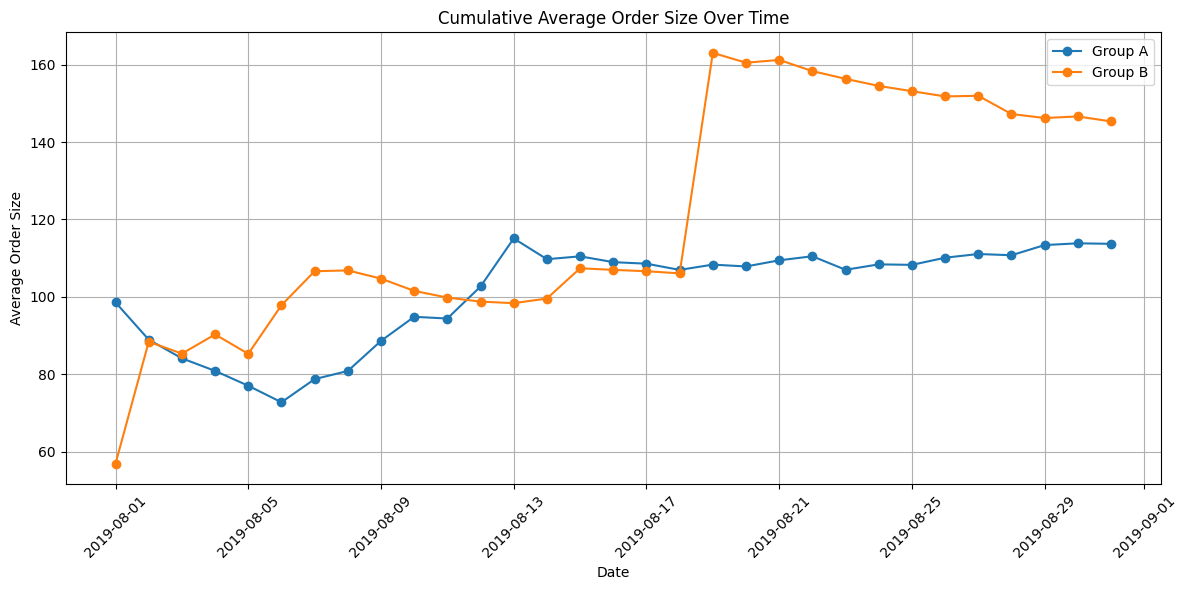

In [ ]:
# Plotting cumulative revenue for both groups
plt.figure(figsize=(12, 6))
plt.plot(cumulativeRevenueA['date'], avgOrderSizeA,
         label='Group A', marker='o')
plt.plot(cumulativeRevenueB['date'], avgOrderSizeB,
         label='Group B', marker='o')
plt.title('Cumulative Average Order Size Over Time')
plt.xlabel('Date')
plt.ylabel('Average Order Size')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Cumulative average ticket per group - observations
- Group B has a higher average ticket than group A in the big picture.
- Group A has higher average ticket in the first day and again between days 12 and 18. With only a handful of orders accumulated so early in the test, the average is noisy and can swing a lot - these early crossovers are less meaningful than the later, more stable trend.
- On day 19, group B's average ticket jumps sharply. This is likely caused by one or a few very large orders (outliers), rather than a real change in user behavior.
- Because of this spike, group B ends the month clearly ahead of group A, but this lead may be driven mostly by that single anomaly.
- This needs to be checked further: in the next steps we will look at order prices and percentiles and compare the results with and without outliers to see if group B is really performing better.